# Предварительная подготовка сырого датасета

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/raw/vehicles.csv')

In [3]:
df

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600


Количество строк и признаков:

In [4]:
df.shape

(426880, 26)

Процент пропусков в каждом признаке:

In [5]:
nan_df = (df.isnull().mean() * 100).reset_index()
nan_df.columns = ["feature", "percentage"]
nan_df.sort_values('percentage', ascending=False, inplace=True)
nan_df

,feature,percentage
21,county,100.000000
16,size,71.767476
9,cylinders,41.622470
8,condition,40.785232
14,VIN,37.725356
15,drive,30.586347
18,paint_color,30.501078
17,type,21.752717
6,manufacturer,4.133714
12,title_status,1.930753


Количество дубликатов:

In [6]:
df.duplicated().sum()

np.int64(0)

Сразу исключим колонки с идентификаторами и ссылками, а также колонки, где больше 70% попусков:

In [7]:
df.drop(columns=['id', 'url', 'region_url', 'image_url', 'county', 'size', 'VIN'], inplace=True)

Снова посмотрим количество дубликатов:

In [8]:
df.duplicated().sum()

np.int64(20)

Удалим 20 дубликатов

In [9]:
df = df.drop_duplicates()

In [10]:
df

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,description,state,lat,long,posting_date
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,fwd,sedan,NaN,Carvana is the safer way to buy a car During t...,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,fwd,sedan,red,Carvana is the safer way to buy a car During t...,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,NaN,hatchback,white,Carvana is the safer way to buy a car During t...,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,fwd,sedan,silver,Carvana is the safer way to buy a car During t...,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600


Видно, что в датасете имеется много экземпляров с пропусками во многих признаках, удалим такие экземпляры.

In [11]:
missing_ratio = df.isna().mean(axis=1)
df = df[missing_ratio <= 0.5]

In [12]:
df

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,description,state,lat,long,posting_date
27,auburn,33590,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,NaN,pickup,white,Carvana is the safer way to buy a car During t...,al,32.590000,-85.480000,2021-05-04T12:31:18-0500
28,auburn,22590,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,NaN,pickup,blue,Carvana is the safer way to buy a car During t...,al,32.590000,-85.480000,2021-05-04T12:31:08-0500
29,auburn,39590,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,NaN,pickup,red,Carvana is the safer way to buy a car During t...,al,32.590000,-85.480000,2021-05-04T12:31:25-0500
30,auburn,30990,2017.0,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,NaN,pickup,red,Carvana is the safer way to buy a car During t...,al,32.590000,-85.480000,2021-05-04T10:41:31-0500
31,auburn,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,2013 F-150 XLT V6 4 Door. Good condition. Leve...,al,32.592000,-85.518900,2021-05-03T14:02:03-0500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,fwd,sedan,NaN,Carvana is the safer way to buy a car During t...,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,fwd,sedan,red,Carvana is the safer way to buy a car During t...,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,NaN,hatchback,white,Carvana is the safer way to buy a car During t...,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,fwd,sedan,silver,Carvana is the safer way to buy a car During t...,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600


Распределение цены:

In [13]:
df["price"].describe().apply(lambda x: f"{x:.2f}")

count        426779.00
mean          75214.37
std        12183723.56
min               0.00
25%            5900.00
50%           13950.00
75%           26489.50
max      3736928711.00
Name: price, dtype: str

В данных имеются выбросы различные выбросы, например, автомобили с ценой 0 или 3736928711. Также медиана и среднее сильно отличается, что еще раз говорит о наличии выбросов.

Выведем график распределения автомобилей с ценой до 100000

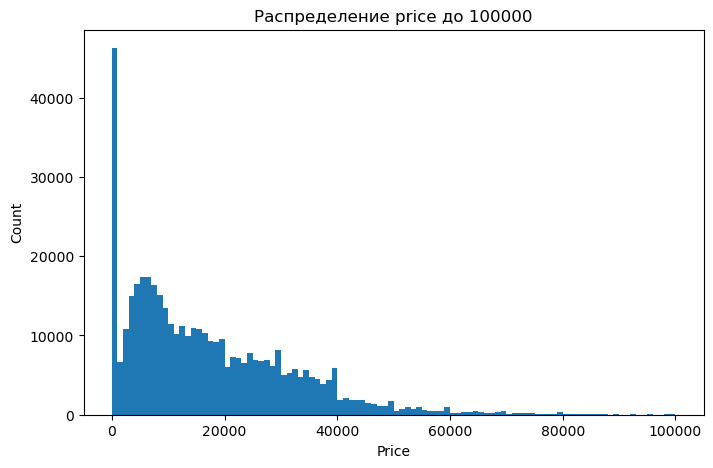

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df.loc[df["price"] < 100000, "price"], bins=100)
plt.title("Распределение price до 100000")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

В датасете огромное число автомобилей с 0 или близкой к этому ценой

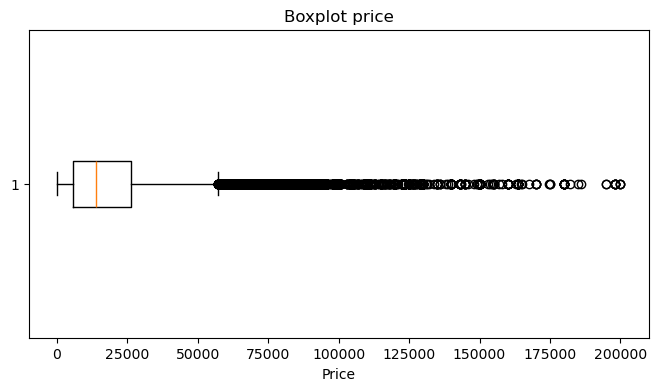

In [15]:
plt.figure(figsize=(8, 4))
plt.boxplot(df.loc[df["price"] < 200000, "price"], vert=False)
plt.title("Boxplot price")
plt.xlabel("Price")
plt.show()

In [16]:
print("Количество объявлений с price = 0:", (df["price"] == 0).sum())
print(
    "Количество объявлений с price < 500 и price != 0:",
    ((df["price"] < 500) & (df["price"] != 0)).sum()
)
print("Количество объявлений с price > 100000:", (df["price"] > 100000).sum())

Количество объявлений с price = 0: 32866
Количество объявлений с price < 500 и price != 0: 9198
Количество объявлений с price > 100000: 655


In [17]:
display(
    df[
        (df["price"] < 500) & (df["price"] != 0)
    ][["price", "year", "manufacturer", "model", "odometer"]].head(20)
)

display(df[df["price"] > 200000][["price", "year", "manufacturer", "model", "odometer"]].head(20))

,price,year,manufacturer,model,odometer
96,80,2004.0,honda,NaN,94020.0
369,199,2017.0,dodge,charger,21737.0
466,1,2012.0,ford,f250 super duty,150000.0
770,199,2017.0,dodge,charger,21737.0
951,199,2017.0,dodge,charger,21737.0
975,1,2002.0,nissan,maxima,196000.0
1009,1,2003.0,cadillac,escalade esv,315836.0
1069,300,1999.0,saturn,sl,265000.0
1174,199,2017.0,dodge,charger,21737.0
1306,199,2017.0,dodge,charger,21737.0


,price,year,manufacturer,model,odometer
280,987654321,1960.0,chevrolet,NaN,999999.0
1838,99999999,1993.0,ford,ranger,99999.0
8495,213000,1933.0,ford,2 dr victoria,999999.0
8901,229500,2018.0,ferrari,488 spider,7910.0
9080,229500,2019.0,NaN,Lamborghini Urus,32922.0
14950,239995,2017.0,ferrari,488 gtb,6450.0
16684,239995,2017.0,ferrari,488 gtb,6012.0
26075,1111111,2014.0,chevrolet,NaN,11.0
28459,249999,2005.0,NaN,lamborghini murcielago,4478.0
29386,1111111111,1999.0,ford,f350 super duty lariat,149000.0


Большинство примеров и вправду оказались мусорными экземплярами. Удалим такие варианты.

In [18]:
df = df[df["price"].between(500, 100000)]

Также видим, что встречаются дубликаты колонок, по этим признкам, проверим дополнительно потенциальные дубликаты:

In [19]:
possible_duplicates_cols = [
    "price", "year", "manufacturer", "model", "odometer", "state"
]

duplicate_ads = df.duplicated(subset=possible_duplicates_cols).sum()

print("Количество возможных дубликатов объявлений:", duplicate_ads)

Количество возможных дубликатов объявлений: 113209


Удалим такие дубликаты.

In [20]:
df = df.drop_duplicates(subset=possible_duplicates_cols)

print("Размер датасета после удаления дубликатов:", df.shape)

Размер датасета после удаления дубликатов: (270851, 19)


Теперь разобьем датасет на train и test

In [22]:
df_train = df.sample(frac=0.7)
df_test = df.drop(df_train.index)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.to_csv("data/interim/train.csv")
df_test.to_csv("data/interim/test.csv")